In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [7]:
# Reading in the retail dataset!
online_retail_df = pd.read_csv('online_retail_2.csv')
print(online_retail_df.shape)
online_retail_df.head(5)

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
print(online_retail_df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [9]:
print(online_retail_df['Quantity'].min())
print(online_retail_df['Quantity'].mean())
print(online_retail_df['Quantity'].max())

-80995
9.9388984711033
80995


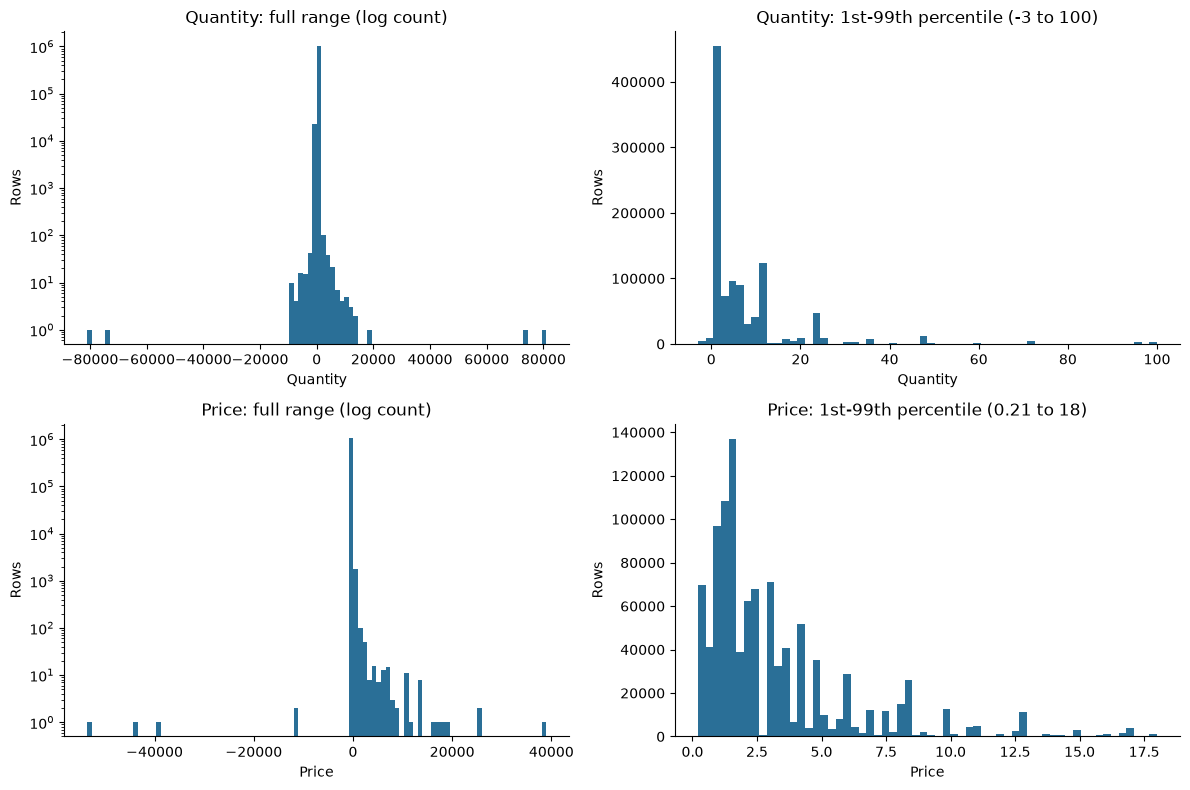

         Quantity       Price
count  1067371.00  1067371.00
mean         9.94        4.65
std        172.71      123.55
min     -80995.00   -53594.36
0.1%      -112.63        0.00
1%          -3.00        0.21
50%          3.00        2.10
99%        100.00       18.00
99.9%      500.00      217.02
max      80995.00    38970.00
Quantity <= 0: 22950 | Price <= 0: 6207
Invoices starting with 'C' (cancellations): 19494


In [10]:
color = "#2a6f97"  # single hue, one variable per panel
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, col in enumerate(["Quantity", "Price"]):
    s = online_retail_df[col].dropna()
    lo, hi = s.quantile([0.01, 0.99])

    # Full range, log-scaled counts so the rare extremes stay visible
    axes[row, 0].hist(s, bins=100, color=color)
    axes[row, 0].set_yscale("log")
    axes[row, 0].set_title(f"{col}: full range (log count)")

    # Zoomed to the 1st-99th percentile to see the bulk of the data
    axes[row, 1].hist(s[s.between(lo, hi)], bins=60, color=color)
    axes[row, 1].set_title(f"{col}: 1st-99th percentile ({lo:g} to {hi:g})")

    for ax in axes[row]:
        ax.set_xlabel(col)
        ax.set_ylabel("Rows")
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Numbers to back up the plots
print(online_retail_df[["Quantity", "Price"]].describe(percentiles=[.001, .01, .5, .99, .999]).round(2))
print("Quantity <= 0:", (online_retail_df.Quantity <= 0).sum(), "| Price <= 0:", (online_retail_df.Price <= 0).sum())
print("Invoices starting with 'C' (cancellations):", online_retail_df.Invoice.astype(str).str.startswith("C").sum())

In [12]:
print(online_retail_df.nlargest(10, "Quantity")[["Invoice","StockCode","Description","Quantity","Price"]])
print(online_retail_df.nsmallest(10, "Quantity")[["Invoice","StockCode","Description","Quantity","Price"]])
print(online_retail_df.nlargest(10, "Price")[["Invoice","StockCode","Description","Quantity","Price"]])
print(online_retail_df.nsmallest(10, "Price")[["Invoice","StockCode","Description","Quantity","Price"]])
# Negative/zero quantity that is NOT a "C" cancellation
odd = online_retail_df[(online_retail_df.Quantity <= 0) & ~online_retail_df.Invoice.astype(str).str.startswith("C")]
print(odd[["Description","Price","Customer ID"]].describe(include="all"))


        Invoice StockCode                         Description  Quantity  Price
1065882  581483     23843         PAPER CRAFT , LITTLE BIRDIE     80995   2.08
587080   541431     23166      MEDIUM CERAMIC TOP STORAGE JAR     74215   1.04
90857    497946     37410  BLACK AND WHITE PAISLEY FLOWER MUG     19152   0.10
127166   501534     21099         SET/6 STRAWBERRY PAPER CUPS     12960   0.10
127168   501534     21091         SET/6 WOODLAND PAPER PLATES     12960   0.10
127169   501534     21085           SET/6 WOODLAND PAPER CUPS     12744   0.10
1027583  578841     84826      ASSTD DESIGN 3D PAPER STICKERS     12540   0.00
127167   501534     21092       SET/6 STRAWBERRY PAPER PLATES     12480   0.10
192197   507637     84016          FLAG OF ST GEORGE CAR FLAG     10200   0.00
135027   502269     21984    PACK OF 12 PINK PAISLEY TISSUES      10000   0.25
         Invoice StockCode                          Description  Quantity  \
1065883  C581484     23843          PAPER CRAFT , LITT

## Cleaning

Two groups of rows are distorting the Quantity/Price distributions and aren't real product sales:

1. **Non-product StockCodes** — postage, manual entries, carriage, discounts, bank charges, Amazon fees, staff stock adjustments, bad-debt write-offs, test rows, and a charity donation code.
2. **Orphaned negative-quantity rows** — Quantity ≤ 0 but the Invoice does *not* start with "C" (i.e. not a real cancellation), and not already covered by rule 1. These are internal write-offs (e.g. "printing smudges/thrown away", "Zebra invcing error") with no Customer ID attached.

`SAMPLES` (StockCode `S`) is left in but flagged — it's a real product movement, just zero revenue, so whether to drop it depends on the analysis.

In [13]:
# 1) Non-product / accounting StockCodes - not real merchandise
non_product_codes = [
    "POST", "DOT",                 # postage
    "M", "m",                      # manual entries
    "C2", "C3",                    # carriage
    "D",                           # discount
    "BANK CHARGES", "AMAZONFEE",   # fees
    "ADJUST", "ADJUST2",           # staff stock adjustments
    "B",                           # bad debt write-off
    "TEST001", "TEST002",          # test rows
    "CRUK",                        # charity donation
]
mask_non_product = online_retail_df["StockCode"].isin(non_product_codes)
print("Non-product rows to drop:", mask_non_product.sum())
print(online_retail_df.loc[mask_non_product, "StockCode"].value_counts())

# 2) Orphaned negative-quantity rows: Quantity <= 0, not a "C" cancellation,
#    and not already caught by rule 1 (internal write-offs, no Customer ID)
is_cancellation = online_retail_df["Invoice"].astype(str).str.startswith("C")
mask_orphan_negative = (online_retail_df["Quantity"] <= 0) & ~is_cancellation & ~mask_non_product
print("\nOrphaned negative-quantity rows to drop:", mask_orphan_negative.sum())

# 3) Flag (but keep) SAMPLES rows for visibility
n_samples = (online_retail_df["StockCode"] == "S").sum()
print("\nSAMPLES rows (kept, zero-revenue):", n_samples)

# 4) Build the cleaned dataframe
online_retail_clean = online_retail_df[~mask_non_product & ~mask_orphan_negative].copy()

print(f"\nOriginal rows: {len(online_retail_df):,}")
print(f"Cleaned rows:  {len(online_retail_clean):,}")
print(f"Dropped:       {len(online_retail_df) - len(online_retail_clean):,}")

Non-product rows to drop: 5708
StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
CRUK              16
TEST001           15
B                  6
m                  5
ADJUST2            3
TEST002            2
C3                 1
Name: count, dtype: int64

Orphaned negative-quantity rows to drop: 3456

SAMPLES rows (kept, zero-revenue): 104

Original rows: 1,067,371
Cleaned rows:  1,058,207
Dropped:       9,164


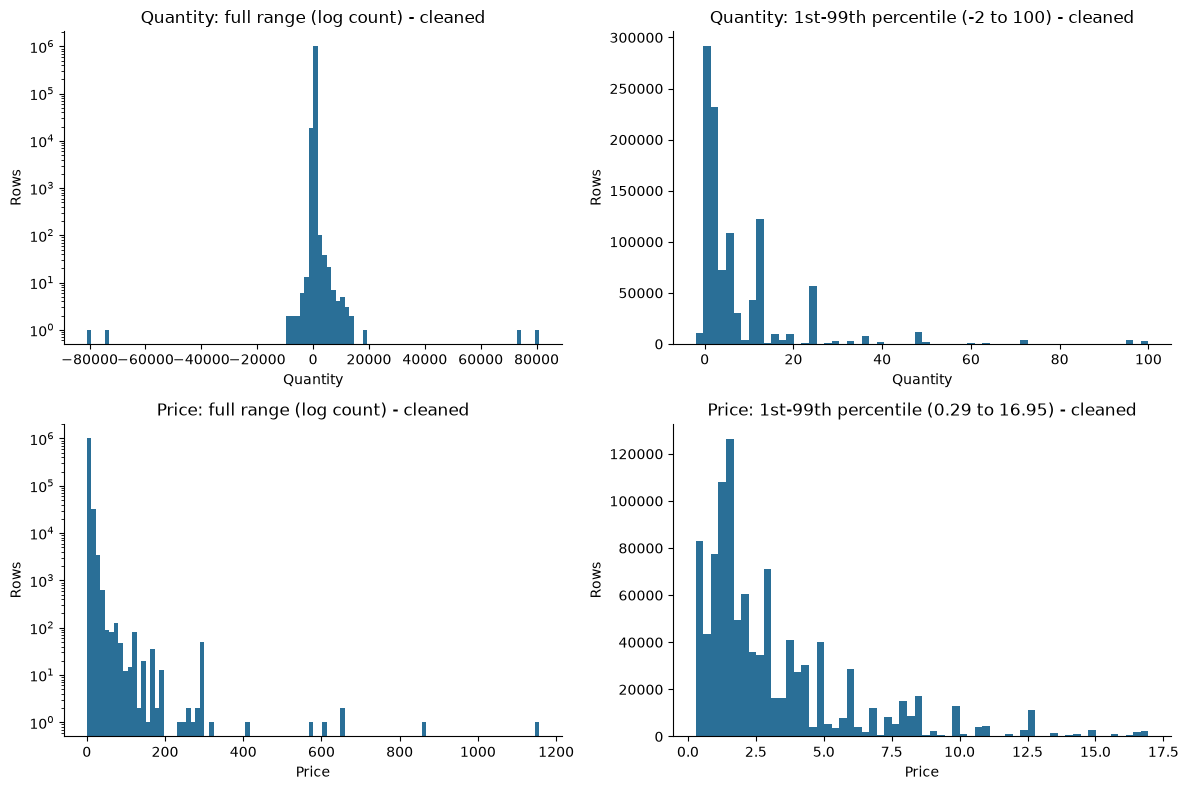

         Quantity       Price
count  1058207.00  1058207.00
mean        10.55        3.36
std        168.79        4.98
min     -80995.00        0.00
0.1%       -32.00        0.00
1%          -2.00        0.29
50%          3.00        2.10
99%        100.00       16.95
99.9%      500.00       35.95
max      80995.00     1157.15


In [14]:
# Re-plot Quantity and Price on the cleaned data
color = "#2a6f97"
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, col in enumerate(["Quantity", "Price"]):
    s = online_retail_clean[col].dropna()
    lo, hi = s.quantile([0.01, 0.99])

    axes[row, 0].hist(s, bins=100, color=color)
    axes[row, 0].set_yscale("log")
    axes[row, 0].set_title(f"{col}: full range (log count) - cleaned")

    axes[row, 1].hist(s[s.between(lo, hi)], bins=60, color=color)
    axes[row, 1].set_title(f"{col}: 1st-99th percentile ({lo:g} to {hi:g}) - cleaned")

    for ax in axes[row]:
        ax.set_xlabel(col)
        ax.set_ylabel("Rows")
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(online_retail_clean[["Quantity", "Price"]].describe(percentiles=[.001, .01, .5, .99, .999]).round(2))

**Price**: Hmm...so we can see that the bad debt write-offs, bank charges, and amazon fees that were stretching the x-axis out to -$50k to +$50k are all gone. The full range panel now spans from 0 to 1200 instead of -50,000 to -40,000 etc. The remainng max of around $1.2K is a real product now.

**Quantity**: This one still looks the same, its not a bug. I actually flagged this out the first time I cleaned. (+80,995) and its cancellation order (-80,995) are real orders that got cancelled, and are not junk data. Hence, I deliberately kept that.

## Some simple exploratory data analysis

For a start, let us try to understand how are we doing in terms of sales per month and MAU *(Monthly Active Users)*

In [15]:
# Monthly revenue and monthly active users (MAU), on the cleaned data
online_retail_clean["InvoiceDate"] = pd.to_datetime(online_retail_clean["InvoiceDate"])
online_retail_clean["Revenue"] = online_retail_clean["Quantity"] * online_retail_clean["Price"]
online_retail_clean["YearMonth"] = online_retail_clean["InvoiceDate"].dt.to_period("M")

# Revenue: all valid sales, including guest/no-Customer-ID orders
monthly_sales = online_retail_clean.groupby("YearMonth")["Revenue"].sum()

# MAU: only rows with a known Customer ID, since guest orders can't be attributed to a user
monthly_mau = (
    online_retail_clean.dropna(subset=["Customer ID"])
    .groupby("YearMonth")["Customer ID"].nunique()
)

print(f"Months covered: {monthly_sales.index.min()} to {monthly_sales.index.max()} ({len(monthly_sales)} months)")
print("\nMonthly revenue:\n", monthly_sales.round(0))
print("\nMonthly active users:\n", monthly_mau)

Months covered: 2009-12 to 2011-12 (25 months)

Monthly revenue:
 YearMonth
2009-12     781759.0
2010-01     606384.0
2010-02     527177.0
2010-03     753484.0
2010-04     638898.0
2010-05     608161.0
2010-06     672977.0
2010-07     617672.0
2010-08     663479.0
2010-09     844134.0
2010-10    1071866.0
2010-11    1400610.0
2010-12    1162634.0
2011-01     580466.0
2011-02     499759.0
2011-03     680474.0
2011-04     483023.0
2011-05     731908.0
2011-06     724491.0
2011-07     677989.0
2011-08     701876.0
2011-09    1013456.0
2011-10    1062543.0
2011-11    1432651.0
2011-12     441375.0
Freq: M, Name: Revenue, dtype: float64

Monthly active users:
 YearMonth
2009-12    1040
2010-01     744
2010-02     803
2010-03    1094
2010-04     987
2010-05    1059
2010-06    1081
2010-07     984
2010-08     963
2010-09    1186
2010-10    1554
2010-11    1681
2010-12     947
2011-01     780
2011-02     791
2011-03    1017
2011-04     896
2011-05    1076
2011-06    1049
2011-07     982
2011-0

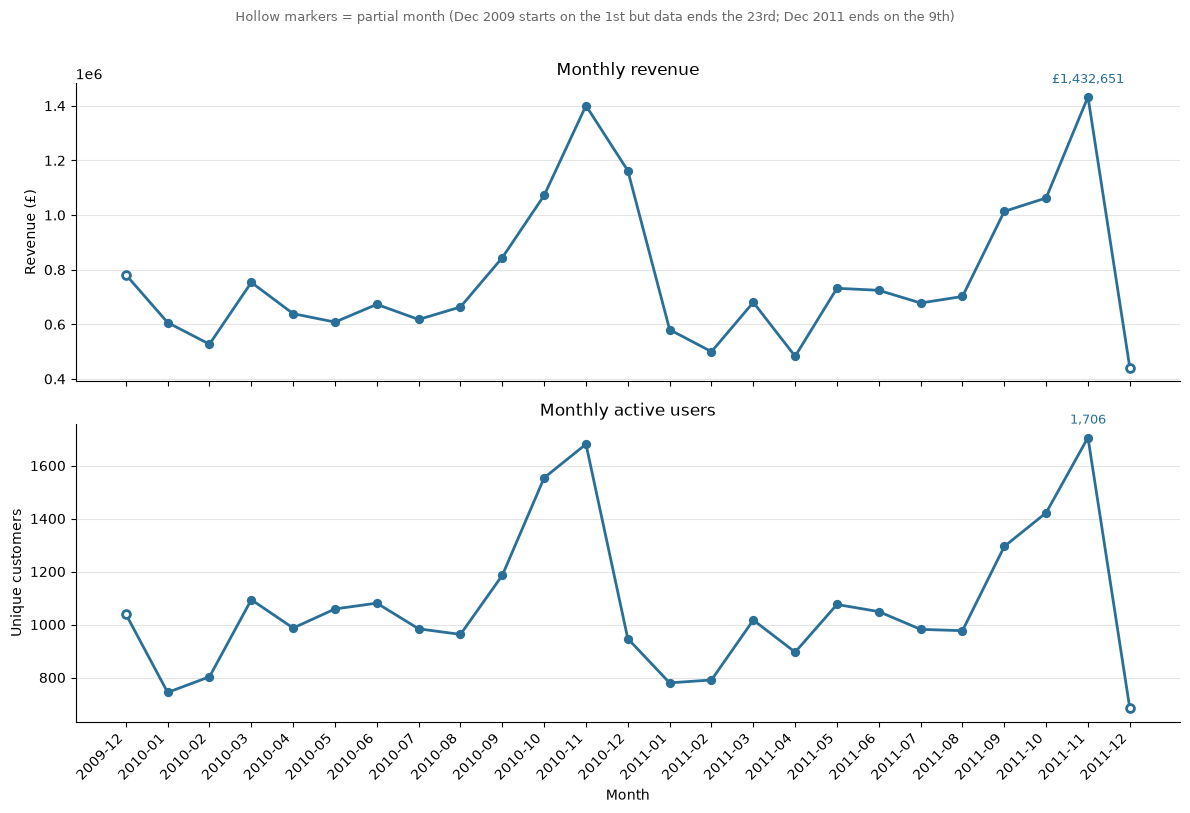

In [17]:
# Plot: monthly revenue (top) and MAU (bottom) as two stacked charts,
# sharing an x-axis rather than a dual y-axis (two different scales)
color = "#2a6f97"
partial_months = {monthly_sales.index.min(), monthly_sales.index.max()}  # incomplete calendar months in the raw data

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

def plot_monthly(ax, series, title, ylabel, fmt):
    x_labels = series.index.astype(str).tolist()
    x = np.arange(len(series))
    is_partial = series.index.isin(partial_months)

    ax.plot(x, series.values, color=color, linewidth=2, zorder=2)
    # solid markers for full months, hollow markers for partial months
    ax.scatter(x[~is_partial], series.values[~is_partial], color=color, s=32, zorder=3)
    ax.scatter(x[is_partial], series.values[is_partial], facecolors="white", edgecolors=color, linewidths=2, s=32, zorder=3)

    # direct-label the latest FULL month so the number isn't read off a partial one
    full_idx = np.where(~is_partial)[0]
    if len(full_idx):
        i = full_idx[-1]
        ax.annotate(fmt(series.values[i]), (i, series.values[i]), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9, color=color)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")

plot_monthly(axes[0], monthly_sales, "Monthly revenue", "Revenue (£)", lambda v: f"£{v:,.0f}")
plot_monthly(axes[1], monthly_mau, "Monthly active users", "Unique customers", lambda v: f"{v:,.0f}")

axes[1].set_xlabel("Month")
fig.suptitle("Hollow markers = partial month (Dec 2009 starts on the 1st but data ends the 23rd; Dec 2011 ends on the 9th)",
             y=1.01, fontsize=9, color="#666666")
plt.tight_layout()
plt.show()

We can see an obvious November peak. This is certainly pre-christmas stocking up for gifts etc - basically buyers are stocking up ahead so it arrives in time. Then it tapers off slightly in December before the partial month cutoff.

**Year on Year seems flat - not growing** 
This is the more intersting finding. When we compare the two full Novembers (the peaky month), 2010-11 is about &1.4M, while 2011-11 is about $1.43M. And if we compare Februaries - 2010-02 is about $527k, while 2011-02 is about $500k. Revenue is actually down slightly..

So despite the strong seasonal swing, the business looks quite essentially flat YoY.